# IMPLEMENT VISION TRANSFORMER FOR IMAGE CLASSIFICATION

## STEP 1: Import necessary libraries

### 1.1. Clone repository

In [1]:
import os
import shutil

# Remove existing folder if it exists
if os.path.exists('DL_self_practice'):
    shutil.rmtree('DL_self_practice')

# Clone repository
!git clone https://github.com/ArrayPowerPlay/DL_self_practice.git

Cloning into 'DL_self_practice'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 45 (delta 9), reused 19 (delta 4), pack-reused 20 (from 1)
Receiving objects: 100% (45/45), 1.74 MiB | 23.17 MiB/s, done.
Resolving deltas: 100% (14/14), done.


### 1.2. Import libraries

In [2]:
import os 
os.chdir('DL_self_practice')
import torch
from utils import spy

## STEP 2: Train ViT model

### 2.1. Train ViT model on FashionMNIST dataset 

Fashion MNIST is an MNIST-like dataset of 70,000 28x28 grayscale fashion image, associated with a label from 10 classes
- Training set: 60,000 examples
- Test set: 10,000 examples

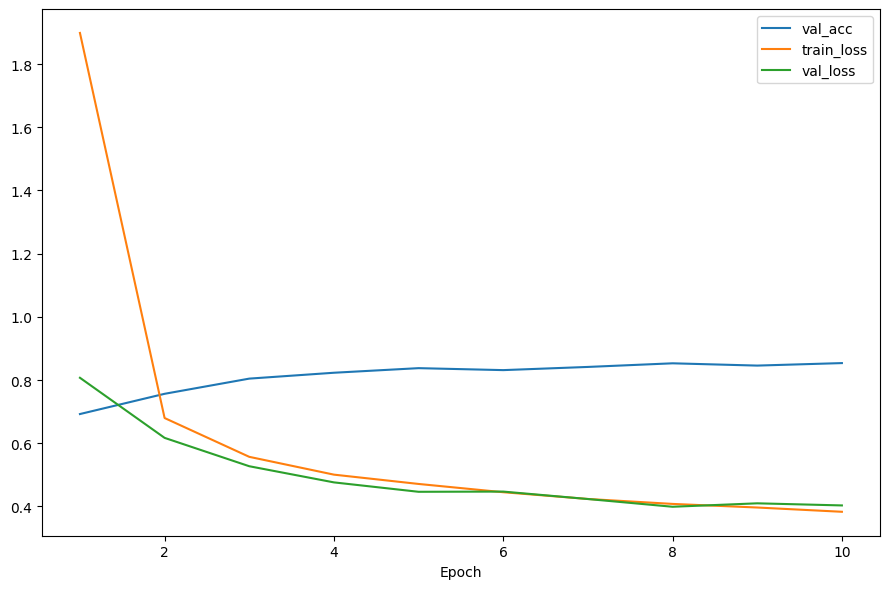

In [3]:
img_size, patch_size = 96, 16
num_hiddens, mlp_num_hiddens, num_heads, num_blks = 512, 2048, 8, 2
emb_dropout, blk_dropout, lr = 0.1, 0.1, 0.1
model = spy.ViT(img_size, patch_size, num_hiddens, mlp_num_hiddens, num_heads,
            num_blks, emb_dropout, blk_dropout, lr)
trainer = spy.Trainer(max_epochs=10)
data = spy.FashionMNIST(batch_size=128, resize=(img_size, img_size))
trainer.fit(model, data)

Show 3 metrics (training loss, validation loss, validation accuracy) of the last epoch

In [4]:
print(model.board['train_loss'][-1])
print(model.board['val_loss'][-1])
print(model.board['val_acc'][-1])

0.3829195073672703
0.40301770198194287
0.8535403481012658


Show predictions of our model

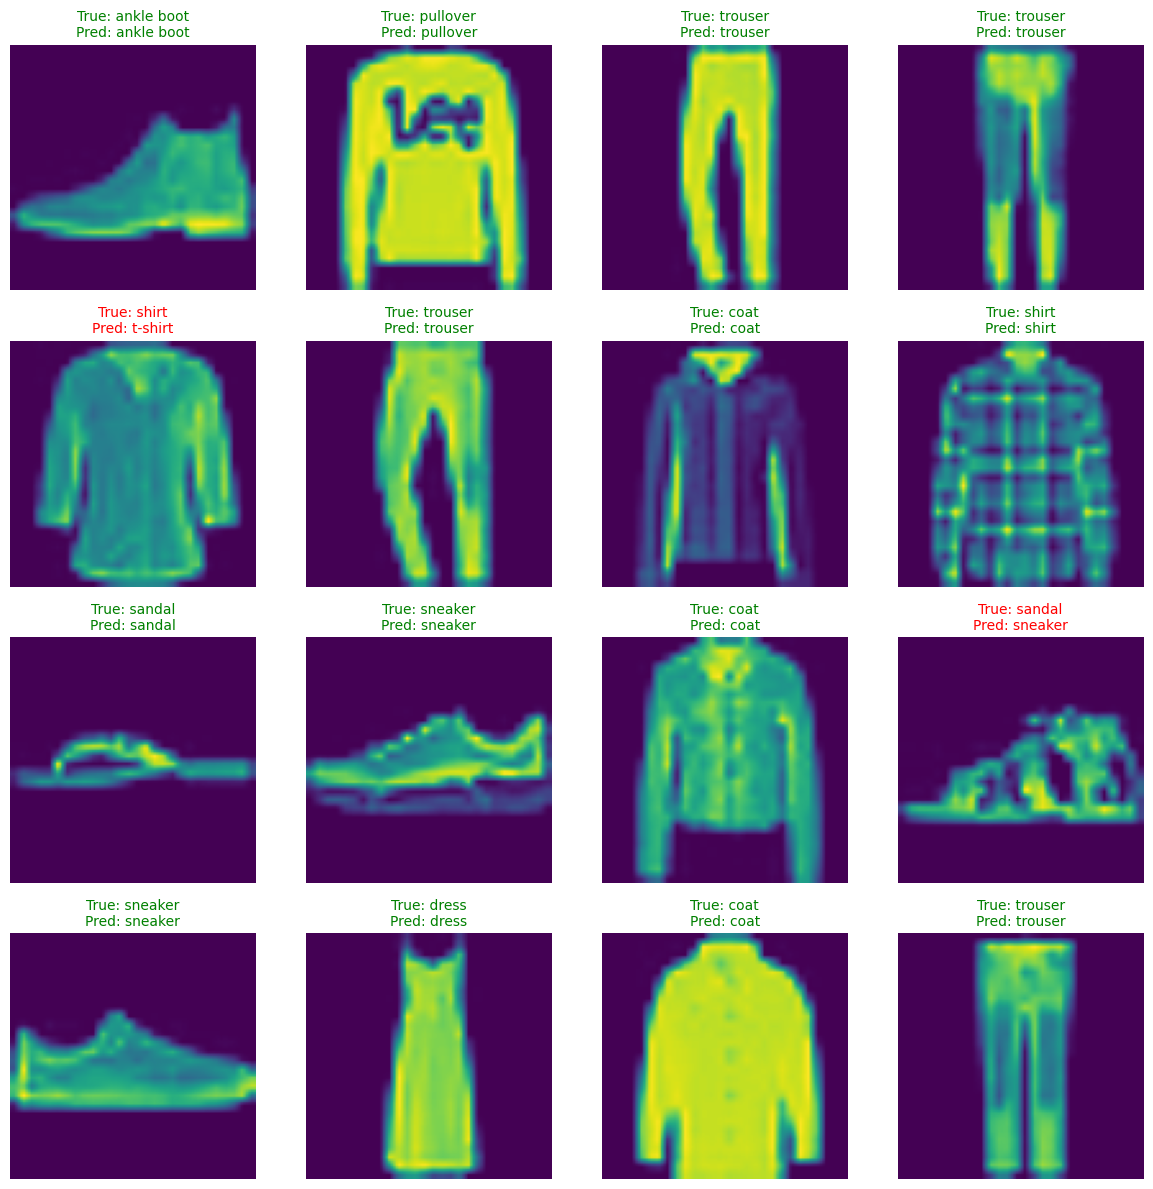

In [5]:
spy.visualize_prediction(model, data, 16, trainer)

### 2.2. Train ViT model on CIFAR10 dataset

The CIFAR-10 dataset consists of 60,000 32x32 colour image in 10 classes, with 6000 per classes
- Training images: 50,000 examples
- Testing images: 10,000 examples

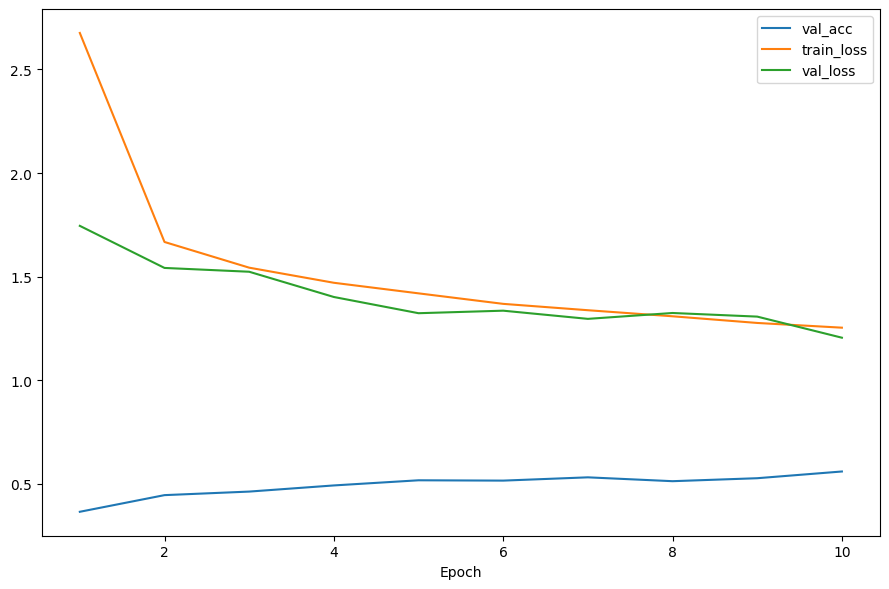

In [ ]:
model_CIFAR10 = spy.ViT(img_size, patch_size, num_hiddens, mlp_num_hiddens, num_heads,
            num_blks, emb_dropout, blk_dropout, lr)
trainer_CIFAR10 = spy.Trainer(max_epochs=10)
data_CIFAR10 = spy.CIFAR10(batch_size=128, resize=(img_size, img_size))
trainer_CIFAR10.fit(model_CIFAR10, data_CIFAR10)

Show 3 metrics (training loss, validation loss, validation accuracy) of the last epoch

In [8]:
print(model.board['train_loss'][-1])
print(model.board['val_loss'][-1])
print(model.board['val_acc'][-1])

0.3829195073672703
0.40301770198194287
0.8535403481012658


Show predictions of our model

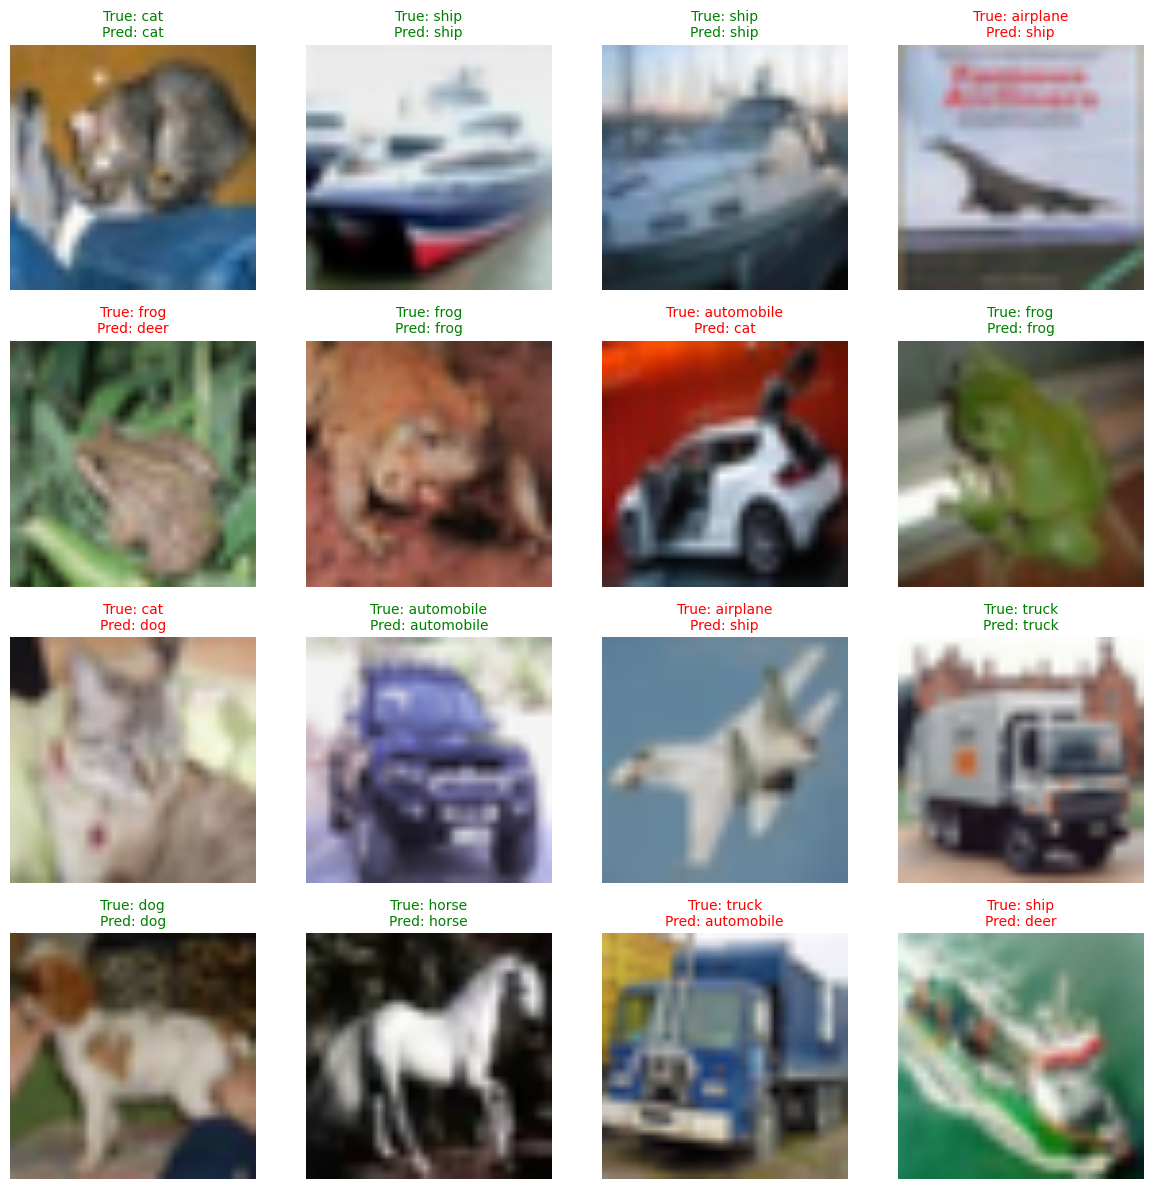

In [9]:
spy.visualize_prediction(model_CIFAR10, data_CIFAR10, 16, trainer)

### 2.3. Train ViT model on CIFAR100 dataset

The CIFAR-100 dataset consists of 60,000 32x32 colour image in 100 classes, with 600 per classes. There are 
500 training images and 100 testing images per class. The 100 classes in the CIFAR-100 are grouped into 20
superclasses. Here, we will work and try to predict the original 100 classes.

- Training images: 50,000 examples
- Testing images: 10,000 examples

In [12]:
model_CIFAR100 = spy.ViT(img_size, patch_size, num_hiddens, mlp_num_hiddens, num_heads,
            num_blks, emb_dropout, blk_dropout, lr, num_classes=100)
trainer_CIFAR100 = spy.Trainer(max_epochs=10)
data_CIFAR100 = spy.CIFAR100(batch_size=64, resize=(img_size, img_size))
trainer_CIFAR100.fit(model_CIFAR100, data_CIFAR100)

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


Show 3 metrics (training loss, validation loss, validation accuracy) of the last epoch

In [ ]:
print(model_CIFAR100.board['train_loss'][-1])
print(model_CIFAR100.board['val_loss'][-1])
print(model_CIFAR100.board['val_acc'][-1])

Show predictions of our model

In [ ]:
spy.visualize_prediction(model_CIFAR100, data_CIFAR100, 16, trainer)